# 📊 Netflix Content Analysis: Data Cleaning & Exploratory Data Analysis (EDA)

## 📌 Project Summary

The goal of this project is to explore how Netflix’s content library has evolved over time by performing a structured data cleaning and exploratory data analysis (EDA) workflow. Using the Netflix Movies & TV Shows dataset, this project focuses on transforming raw, inconsistent data into meaningful insights about platform growth, content trends, and strategic shifts.

Through systematic cleaning, feature engineering, and visualization, the project aims to uncover patterns such as:
- How Netflix’s catalog has expanded year by year  
- Differences in growth between Movies and TV Shows  
- Trends in genres, ratings, countries, and content duration  
- Insights that reflect Netflix’s evolving content strategy  

This project demonstrates practical data science skills including data wrangling, feature creation, visualization, and analytical storytelling — all essential components of a strong portfolio‑ready analysis.

In [369]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [370]:
sns.set(style="whitegrid")
df = pd.read_csv("netflix_titles.csv")
df.head()

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


# Fill missing values
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Unknown")
df['duration'] = df['duration'].fillna("Unknown")

# Create a new column for year added
df['year_added'] = df['date_added'].dt.year

In [371]:
df['date_added'].isna().sum()


np.int64(98)

In [372]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8709 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
 12  year_added    8709 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(10)
memory usage: 894.6 KB


In [373]:
df.describe(include='all')


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
count,8807,8807,8807,8807,8807,8807,8709,8807.000000,8807,8807,8807,8807,8709.000000
unique,8807,2,8807,4529,7693,749,NaN,NaN,18,221,514,8775,NaN
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN
freq,1,6131,1,2634,825,2818,NaN,NaN,3207,1793,362,4,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-23 01:45:29.452290,2014.180198,NaN,NaN,NaN,NaN,2018.887932
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,2008.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-20 00:00:00,2013.000000,NaN,NaN,NaN,NaN,2018.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-12 00:00:00,2017.000000,NaN,NaN,NaN,NaN,2019.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-26 00:00:00,2019.000000,NaN,NaN,NaN,NaN,2020.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,2021.000000


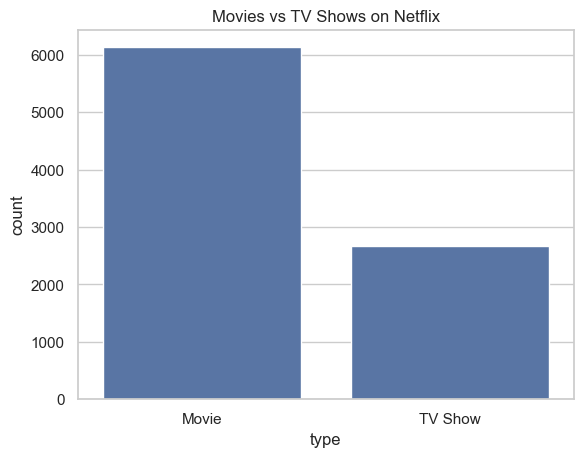

In [374]:
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.show()


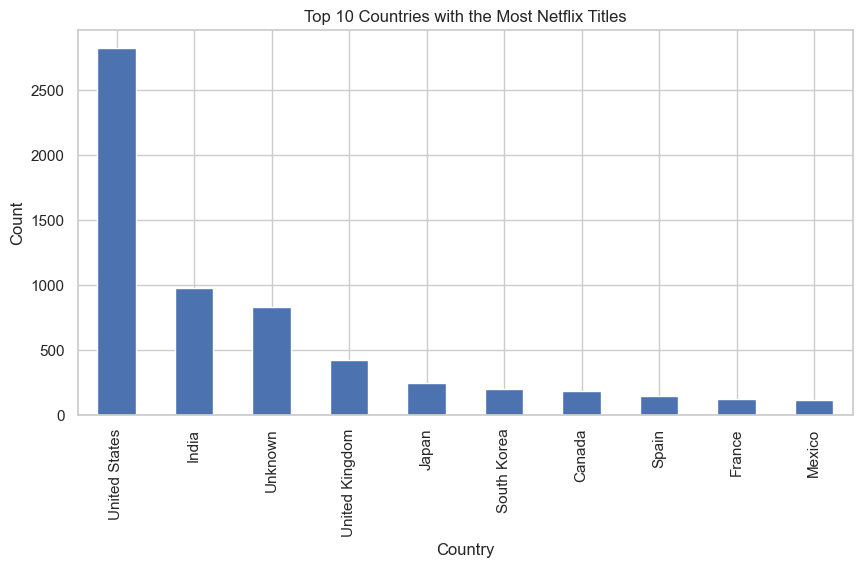

In [375]:
df['country'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries with the Most Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()


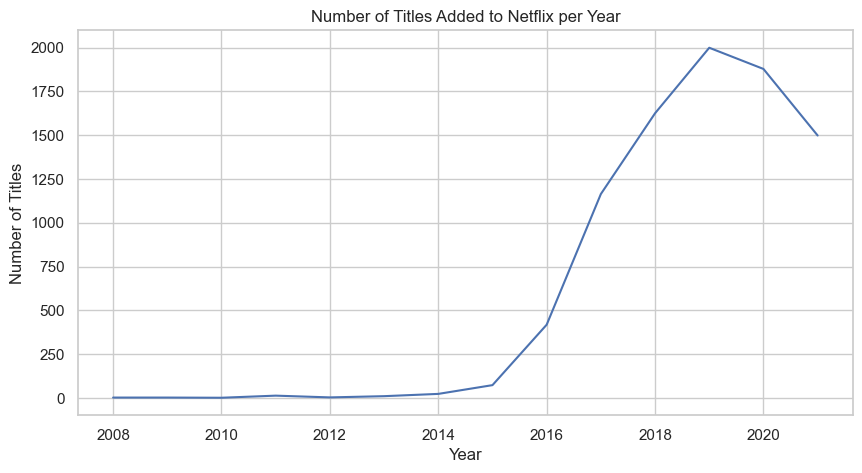

In [376]:
df['year_added'].value_counts().sort_index().plot(kind='line', figsize=(10,5))
plt.title("Number of Titles Added to Netflix per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()


## 📌 Summary of Progress So Far

### 1. Cleaned the `date_added` Column
Converted the raw date strings into proper datetime objects.  
This ensures consistent formatting and enables accurate time‑based analysis.

### 2. Extracted the `year_added` Feature
Created a new column (`year_added`) from the cleaned dates.  
This feature allows us to analyze trends in Netflix content additions over time.

### 3. Visualized Growth of Netflix’s Library
Plotted the number of titles added each year using a line chart.  
This visualization highlights how Netflix’s catalog has expanded, revealing patterns such as growth periods, slowdowns, or spikes.

## 📌 Next Analysis: Movies vs TV Shows Over Time

### 🎯 Goal
Understand how Netflix’s content strategy has evolved by comparing the number of **Movies** and **TV Shows** added each year.

### 🧠 Why This Matters
Analyzing Movies vs TV Shows over time helps reveal:
- Shifts in Netflix’s production and acquisition strategy  
- Whether Netflix is investing more in series or films  
- How content variety has changed across years  

This is a key insight for understanding platform growth and audience targeting.

### 🛠️ What We Will Do
1. Group the dataset by `year_added` and `type`  
2. Count how many Movies and TV Shows were added each year  
3. Visualize the trend using a line chart  

### 📈 Expected Insight
This visualization will show whether Netflix:
- Increased its focus on TV Shows in recent years  
- Had periods of rapid expansion  
- Balanced both content types or shifted toward one

📈 Content Added Over Time: 

Understanding how Netflix’s catalog has grown over the years helps reveal the platform’s expansion strategy. By grouping titles by the year they were added, we can visualize major growth periods and identify when Netflix accelerated content acquisition.

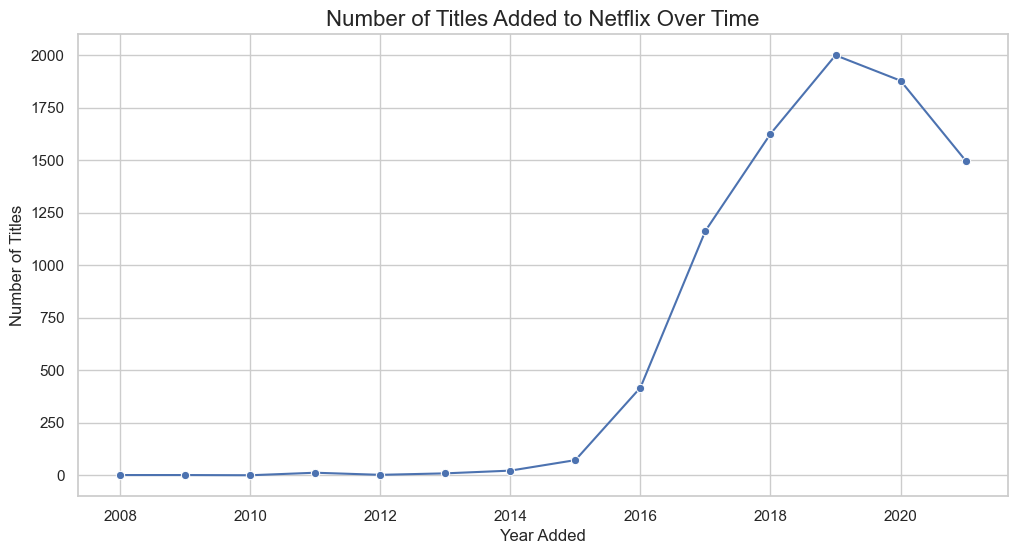

In [377]:
# Counting titles added per year
titles_per_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=titles_per_year.index, y=titles_per_year.values, marker='o')
plt.title("Number of Titles Added to Netflix Over Time", fontsize=16)
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()


🔍 Insight:
The chart shows clear growth in Netflix’s content library over time, with especially rapid expansion in the mid‑2010s. This period aligns with Netflix’s global expansion and increased investment in original content. The trend highlights how the platform shifted from a smaller catalog to a major global streaming service.

🎬 Movies vs TV Shows:

Understanding the balance between Movies and TV Shows helps reveal Netflix’s content strategy. This visualization shows how the platform distributes its content types and whether one category dominates the catalog.

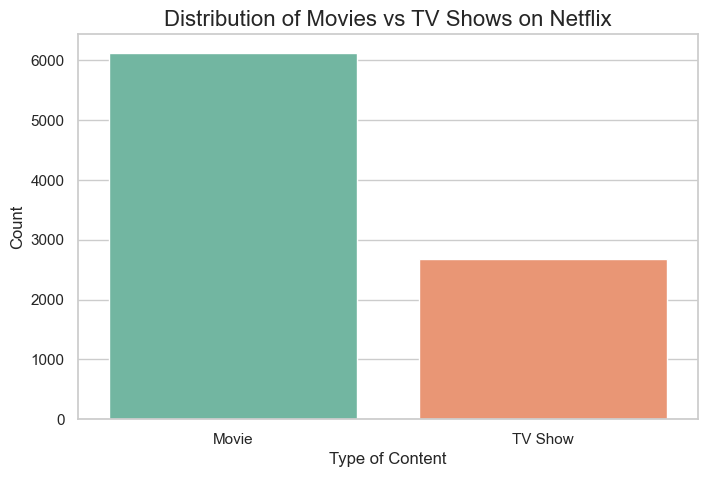

In [378]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title("Distribution of Movies vs TV Shows on Netflix", fontsize=16)
plt.xlabel("Type of Content")
plt.ylabel("Count")
plt.show()



🔍 Insight: 
Movies make up the majority of Netflix’s catalog, significantly outnumbering TV Shows. This suggests that while Netflix invests heavily in series, the platform still relies on a large volume of movie content to attract and retain viewers.

🌍 Top Countries Producing Content:

Netflix sources content from all over the world. By identifying the countries that appear most frequently in the dataset, we can understand which regions contribute the most to Netflix’s catalog and how global the platform truly is


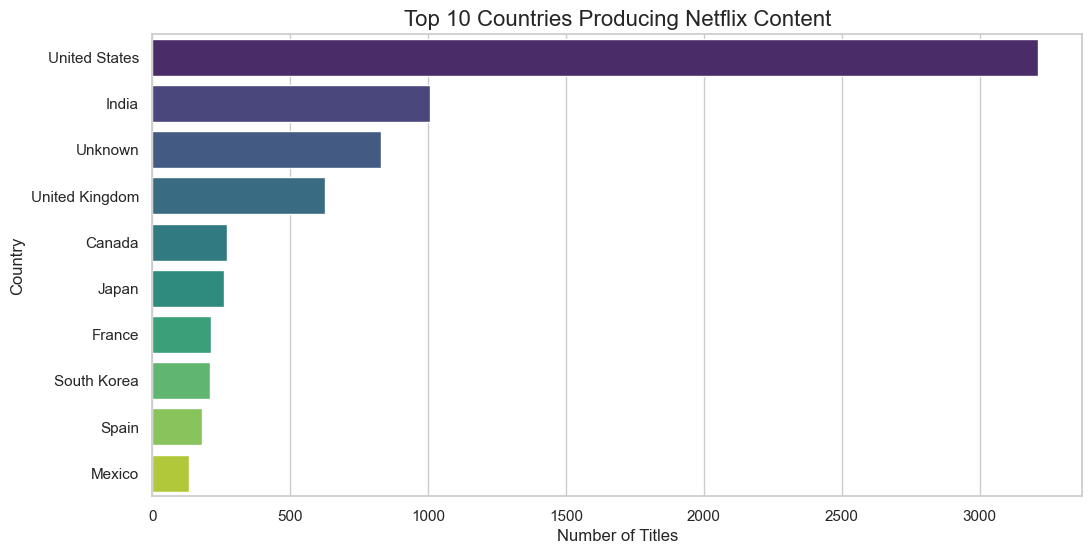

In [379]:
# Extract the first listed country
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette='viridis',
    legend=False
)
plt.title("Top 10 Countries Producing Netflix Content", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


🔍 Insight: 
The United States appears as the dominant producer of Netflix content, followed by countries such as India, the United Kingdom, and Canada. This reflects Netflix’s strong presence in North America and its growing investment in international markets, especially in Asia and Europe.


🎭 Most Common Genres:

Each Netflix title is assigned one or more genres in the listed_in column. By identifying the most frequent genres, we can understand what types of content dominate the platform and what Netflix prioritizes in its catalog

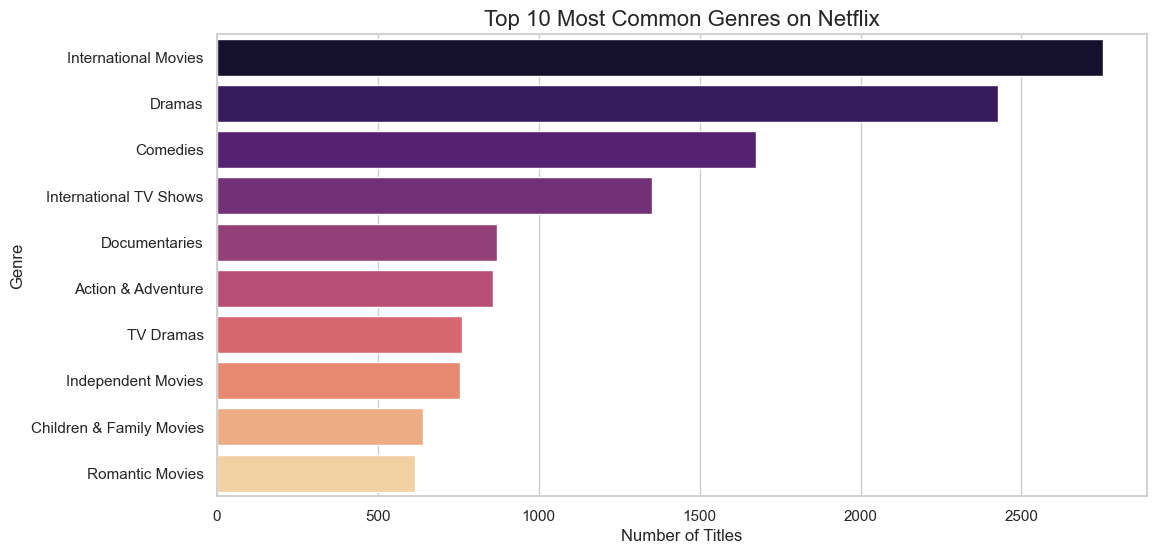

In [380]:
# Split genres and count frequency
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette='magma',
    legend=False
)
plt.title("Top 10 Most Common Genres on Netflix", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()



🔍 Insight:
Genres such as International Movies, Dramas, and Comedies appear most frequently in Netflix’s catalog. This reflects Netflix’s strategy of offering a wide range of globally appealing content while maintaining strong representation in popular categories like drama and comedy.

🔞 Ratings Distribution:

Netflix titles come with different maturity ratings such as TV-MA, TV-14, PG, and others. Analyzing the distribution of these ratings helps reveal whether Netflix’s catalog leans more toward adult-oriented content or family-friendly programming.

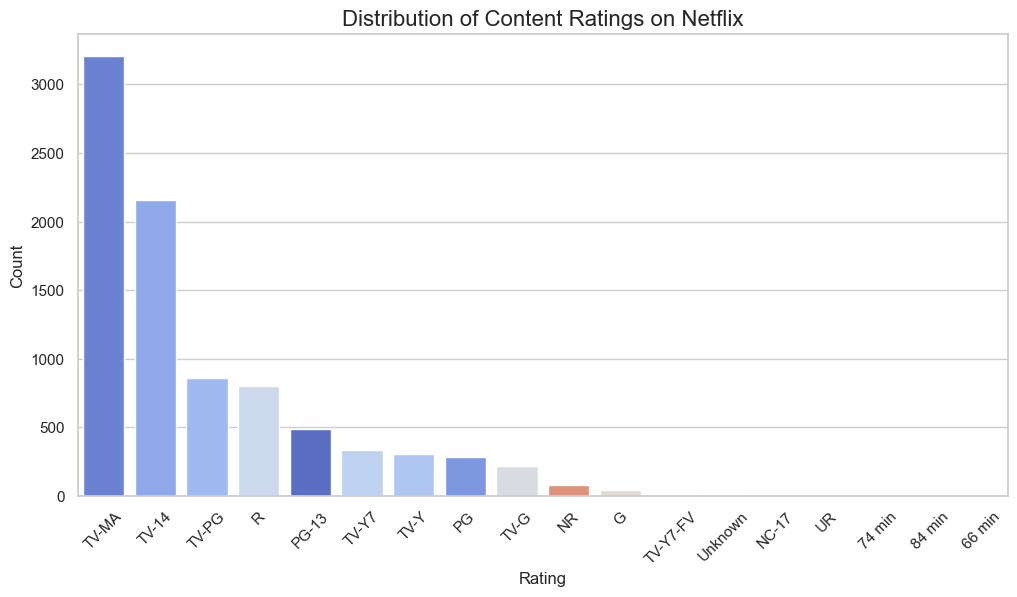

In [381]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index,
    hue=df['rating'],
    palette='coolwarm',
    legend=False
)
plt.title("Distribution of Content Ratings on Netflix", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


🔍 Insight:
The distribution shows that Netflix has a strong concentration of TV-MA and TV-14 content, indicating a significant focus on mature and teen audiences. Family-friendly ratings such as PG and TV-G appear less frequently, suggesting that Netflix’s catalog leans more toward older viewers.

🕒 Duration Analysis: Movies vs TV Shows: 
Netflix provides duration information differently for Movies and TV Shows. Movies list their length in minutes, while TV Shows list the number of seasons. Analyzing these separately helps us understand typical movie lengths and how long most series run.

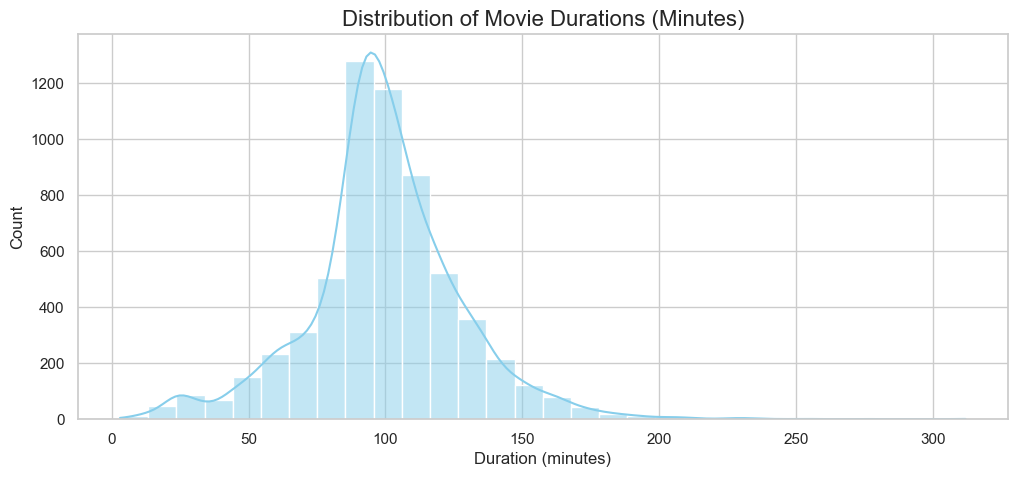

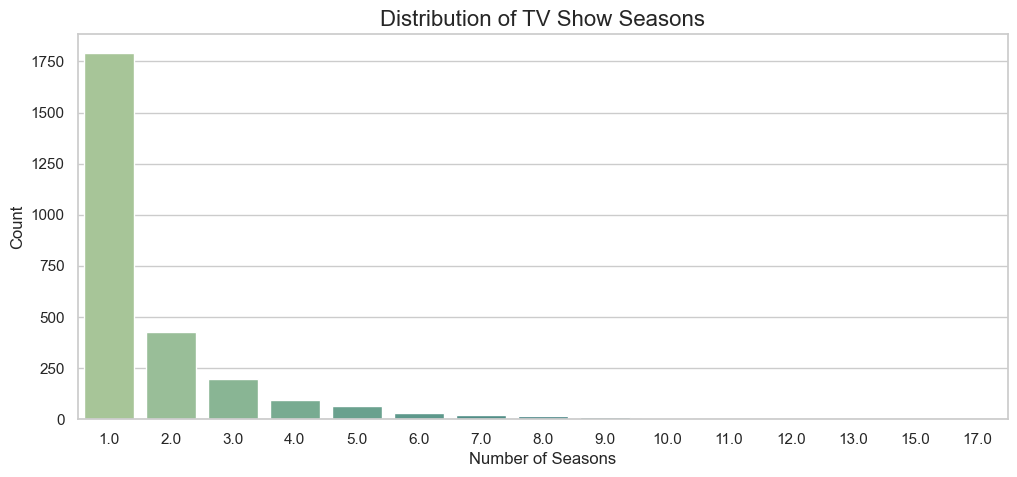

In [382]:
# Separate movies and TV shows
movies = df[df['type'] == 'Movie'].copy()
shows = df[df['type'] == 'TV Show'].copy()

# Extract duration values
movies['duration_minutes'] = movies['duration'].str.extract(r'(\d+)').astype(float)
shows['seasons'] = shows['duration'].str.extract(r'(\d+)').astype(float)

# Plot movie duration distribution
plt.figure(figsize=(12,5))
sns.histplot(movies['duration_minutes'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Movie Durations (Minutes)", fontsize=16)
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

# Plot TV show seasons distribution
plt.figure(figsize=(12,5))
sns.countplot(
    x=shows['seasons'],
    hue=shows['seasons'],
    palette='crest',
    legend=False
)
plt.title("Distribution of TV Show Seasons", fontsize=16)
plt.xlabel("Number of Seasons")
plt.ylabel("Count")
plt.show()


🔍 Insight: 
Most Netflix movies fall between 80 and 120 minutes, reflecting standard feature-length formats. TV Shows, on the other hand, are dominated by single-season titles, suggesting a strong presence of limited series, documentaries, and short-run productions. Multi-season shows exist but are far less common in the dataset.

📌 Conclusion & Key Insights:

This exploratory analysis provides a clear overview of Netflix’s content catalog and highlights several important patterns in how the platform has evolved over time.
1. Netflix’s catalog has grown rapidly, especially during the mid‑2010s, aligning with the company’s global expansion and increased investment in original productions.
2. Movies significantly outnumber TV Shows, suggesting that while Netflix is known for its series, the platform still relies heavily on a large library of films.
3. The United States remains the dominant content producer, but countries like India, the United Kingdom, and Canada also contribute heavily, reflecting Netflix’s global reach and diverse acquisition strategy.
4. Genres such as International Movies, Dramas, and Comedies appear most frequently, showing Netflix’s emphasis on globally appealing and story‑driven content.
5. Ratings distribution is heavily skewed toward TV‑MA and TV‑14, indicating that Netflix’s catalog leans toward mature and teen audiences rather than family‑focused programming.
6. Most movies fall between 80–120 minutes, consistent with standard feature‑length films, while TV Shows are dominated by single‑season titles, highlighting the popularity of limited series and documentary formats.
Overall, the analysis shows that Netflix has grown into a global content powerhouse with a strong focus on mature storytelling, international markets, and a balanced mix of films and series. These insights provide a solid foundation for deeper analysis, such as recommendation systems, clustering, or predictive modeling.

This project demonstrates practical skills in data cleaning, visualization, and exploratory analysis using Python, pandas, and Seaborn.